# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
from cases.open_space.ngsolve_geometries import AnularDomain

R = 1.
r = 0.2


Lc = 2.
lc = 0.05

mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=Lc, lc=lc)


In [2]:
mesh.n_triangles

222

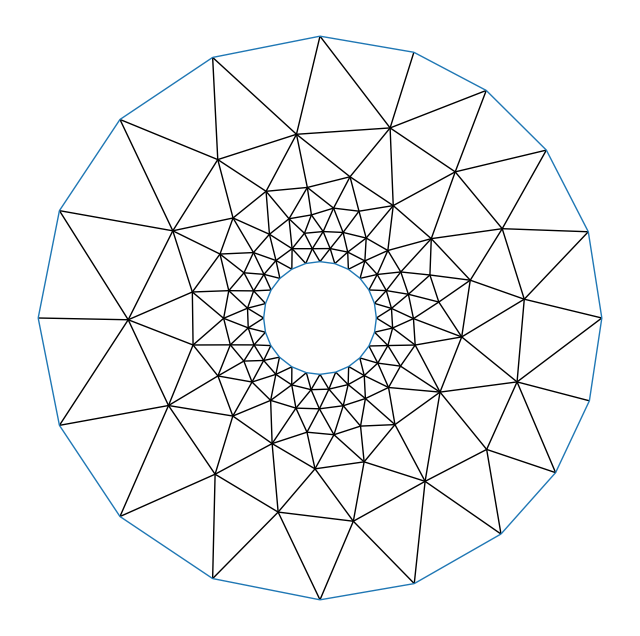

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [5]:
# mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R,r])
mesh.curve_boundaries([Boundaries.SIGMA], radius=[R])

mesh.curved_boundaries


[<Boundaries.SIGMA: 'Sigma'>]

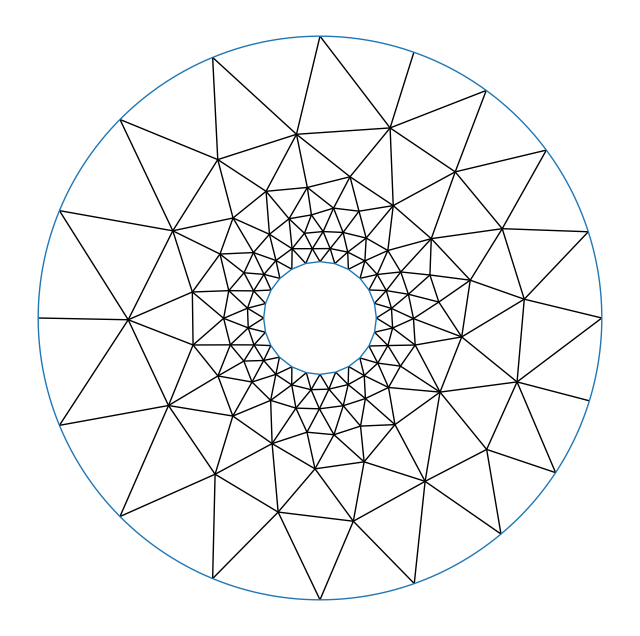

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=-1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
# boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}


Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5

numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [12]:
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.dg.parameters import Elementwise

Regions = mesh.regions


refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : 1.})
k = 8.0
Ntheta = 14
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [13]:
basis.N_DOF

3108

In [14]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [15]:
assembler._regions_RHS_term

[<Boundaries.D_OMEGA: 'd_Omega'>]

so we can set the problem:

In [16]:
from trefftz.problem import Problem
from cases.open_space.exact import CircularDirichlet


P = Problem(mesh=mesh,
            wavenumber=k,
            basis=basis,
            boundary_conditions=boundary_conditions,
            assembler=assembler,
            direct_solver=True,
            u=lambda x, y: CircularDirichlet(x, y, R=r, k=k, theta_inc=np.pi))

In [17]:
P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 18/18 [00:01<00:00, 17.65edge/s]


region: d_Omega


Interior: 100%|██████████| 312/312 [00:00<00:00, 720.19edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 18/18 [01:59<00:00,  6.61s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 316344 stored elements and shape (3108, 3108)>

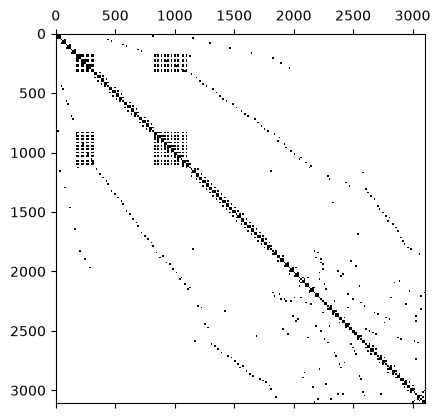

In [18]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [19]:
P.assemble_RHS()

array([ 0.06765372+0.14126996j, -0.08873647+0.33914794j,
       -0.39664734+0.33905247j, ...,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ], shape=(3108,))

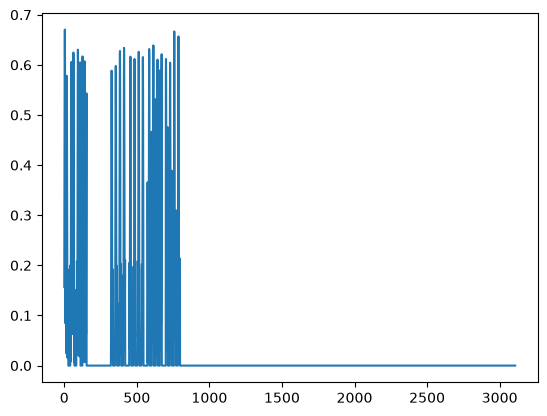

In [20]:
import numpy as np 
plt.plot(np.abs(P.b))

In [21]:
P.solve()

In [22]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 1.61794748e+03+9.25376459e+04j,  5.94936641e+04-6.60422769e+04j,
        -8.31214801e+04+1.59463551e+04j, ...,
        -9.37983497e+04-1.22181634e+04j,  9.01711005e+04+3.20185665e+04j,
        -6.26077547e+04-7.14009460e+04j],
       [-1.50506265e+04+1.29765973e+04j,  2.16670087e+04+2.06641810e+03j,
        -1.57681305e+04-1.29520702e+04j, ...,
        -1.99140400e+03+2.52678376e+03j,  6.68252064e+03+5.19332392e+03j,
        -3.72368747e+02-1.50844551e+04j],
       [ 1.29005125e+04-1.48407145e+04j, -1.98723847e+04+2.12488495e+03j,
         1.75608403e+04+9.91581769e+03j, ...,
         1.43623873e+04+1.29300839e+04j, -1.02875510e+04-1.62956016e+04j,
         1.71413820e+02+1.93807067e+04j],
       ...,
       [-2.83198834e+00+1.30367598e+00j,  4.33175921e-01+2.48804133e+00j,
         2.11691808e+00+1.46085487e-01j, ...,
        -3.99943709e+00-1.72837601e+00j,  3.53852472e+00+1.35360446e+00j,
        -1.33903697e+00-3.39147467e+00j],
       [-8.77727469e+00-4.17212470e+01j, -4.

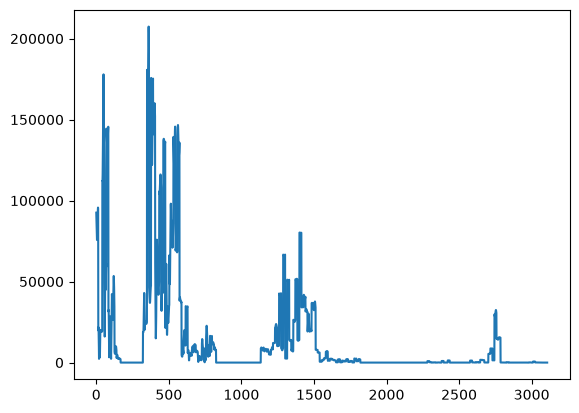

In [23]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

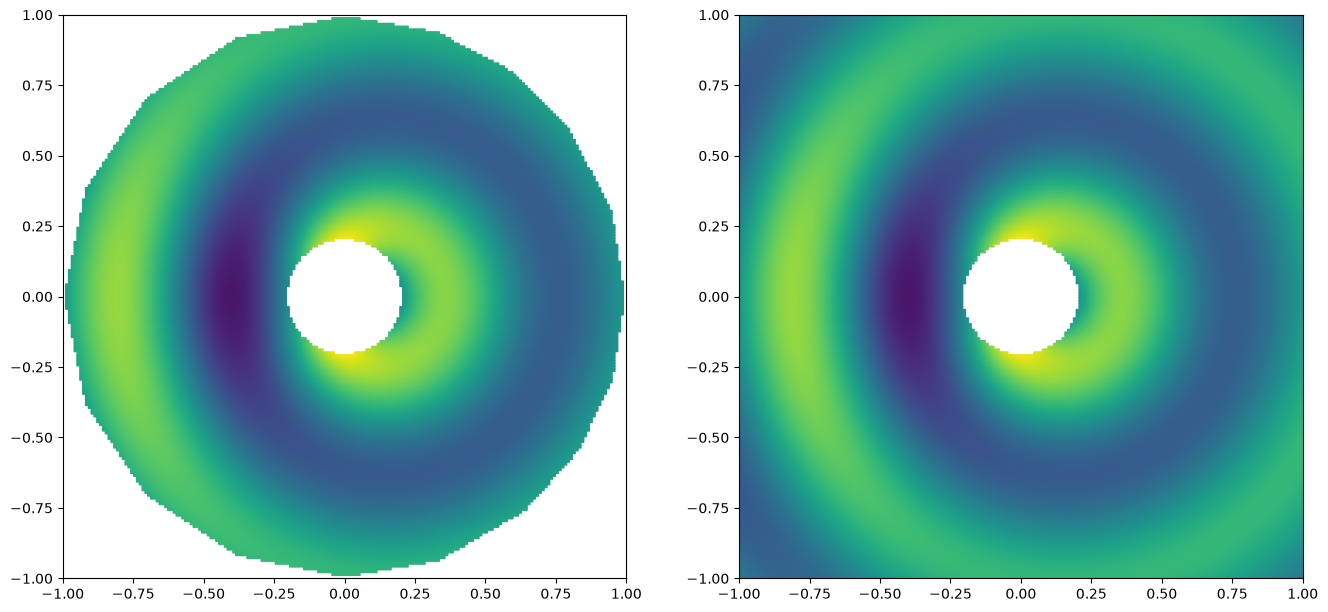

In [28]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
# U_s = CircularDirichlet(X, Y, R=r, k=k, theta_inc=np.pi)
# U_inc = np.exp(-1j*k*X)
# U = U_s + U_inc
U = -P.u(X, Y)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), vmin=-1, vmax=1, shading="gouraud")
ax[0].axis('square')
# ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
# ax[1].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

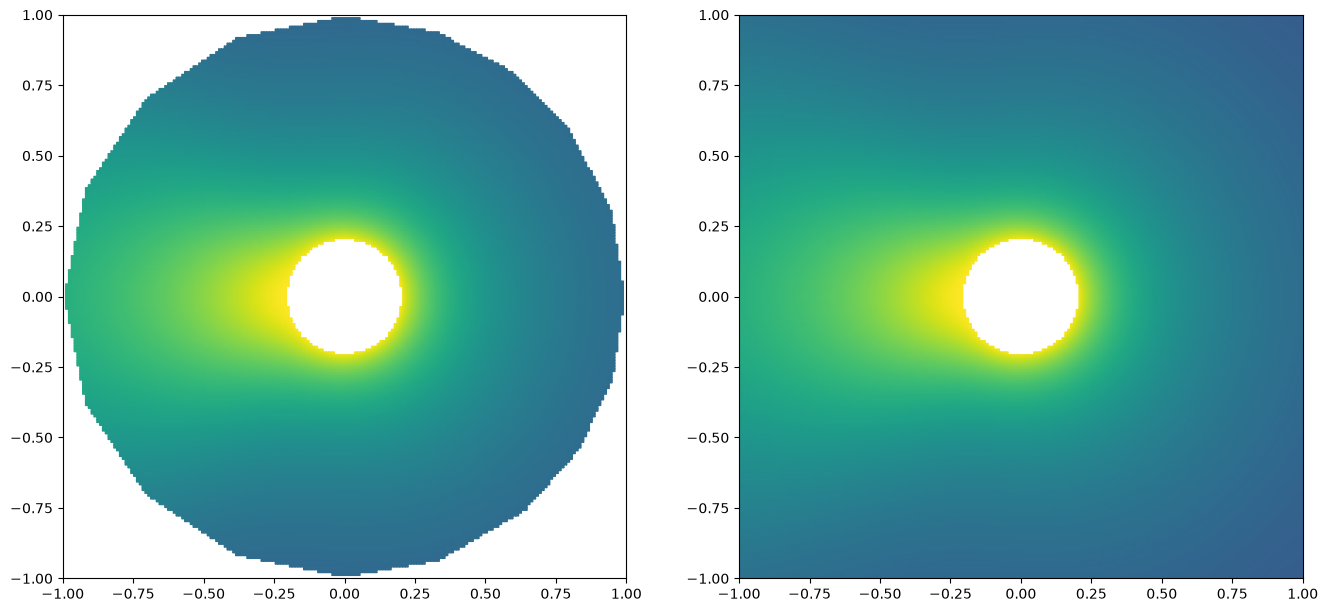

In [29]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), vmin=0, vmax=1, shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.abs(U), vmin=0, vmax=1, shading="gouraud")
ax[1].axis('square')


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.02243707707342177
0.028456835432064616
0.022960232587192476
0.021994749927032473
0.022806958424650567
0.026245513480516493
0.024816810613863104
0.03414879373562598
0.034869217346228776
0.10450335195214558
0.10350228508508554
nan
0.005640475367294517
nan
nan
nan
nan
nan
nan
0.005716955338259383
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.0064692921190387075
nan
nan
nan
0.006427921066231971
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.028867441630959407
0.02655409196869581
0.01885397347495288
0.02212899273740697
0.020473255120369082
0.020875955059175614
0.024323789924042525
0.02405282128476859
0.02351306718889044
0.024747477711562473
0.02160191377080132
0.026065856325740468
0.04343885167527373
0.035172349910248084
0.0896110072825659
0.0599139524040416
0.123944777555837
0.08624292446047445
0.11358160128120079
0.04387749316714196
0.058461374731040405
0.028338143303744578
0.005690423067989226
0.005121467350237143
0.0058062751470416485
0.0

Text(0.5, 1.0, 'nan')

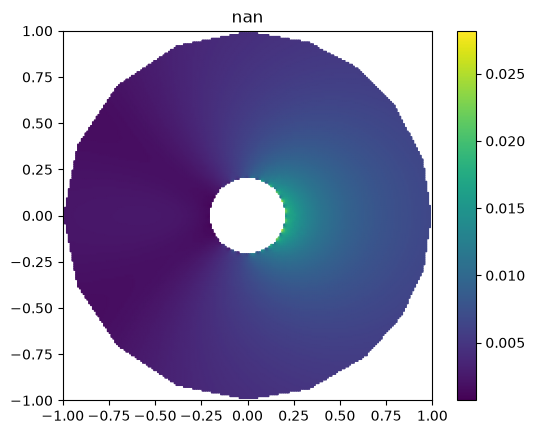

In [30]:
plt.pcolormesh(X, Y, np.abs(U - U_h), shading="gouraud")
plt.axis("square")
plt.colorbar()
plt.title(P.compute_error())